<a href="https://colab.research.google.com/github/everblessed31/Amazon-Products-Review-Analysis/blob/main/Paysim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
from re import U
from google.colab import files
uploaded=files.upload()
print(uploaded)

Saving paysim.csv to paysim.csv
{'paysim.csv': b'step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,naeDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud\r\n7271,CASH_OUT,77.53,7093073,6280.96,6173.58,5391649,3589.4,3641.92,0,0\r\n861,CASH_IN,2742.47,2349590,4618.99,1757,3900203,3741.38,6354.27,0,0\r\n5391,PAYMENT,2151.95,6366645,5648.11,3475.55,2650870,3663.49,5775.52,1,0\r\n5192,DEBIT,3240.3,6629905,2704.62,0,8062215,3068.16,6242.69,0,0\r\n5735,CASH_OUT,222.68,4045529,5170.42,4974.62,8559012,5298.55,5519.21,0,0\r\n6266,PAYMENT,72.44,6440107,0,0,4620597,0,9.76,0,0\r\n467,CASH_OUT,1420.91,8103260,4626.21,3191.3,6519803,3219.32,4670.66,0,0\r\n4427,CASH_OUT,980.72,8081530,1739.05,694.38,6687136,4694.7,5730.84,0,0\r\n5579,PAYMENT,1239.6,3897706,7411.99,6198.15,8789573,162.91,1400.95,0,0\r\n8323,PAYMENT,9556.29,9282356,6554.81,0,1667538,4256.88,13763.97,0,0\r\n1686,PAYMENT,7063.75,4201473,5933.34,0,5607455,1858.26,8936.33,0,0\r\n770,PAYMENT,5705.53,7507660,8042.01,2365.01,301333

In [18]:

# ======================================================================
# Application of Big Data Analytics for Fraud Detection in Mobile Money Transactions
# ======================================================================
# Author: Blessing Ogar
# Project: Postgraduate Diploma Research - Southwestern University (2025)
# ======================================================================

# -------------------------------
# Listing 3.1: Python Code for Data Loading
# -------------------------------

import pandas as pd

# Load dataset (replace with your actual file path)
file_path = "paysim.csv"
uploaded = pd.read_csv(file_path)

print("Dataset Loaded Successfully!")
print(uploaded.head())
print(uploaded.info())
print("Missing Values per Column:\n", uploaded.isnull().sum())


# -------------------------------
# Listing 3.2: Python Code for Data Preprocessing and Feature Engineering
# -------------------------------

from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE

# Drop irrelevant columns
df = uploaded.drop(['nameOrig', 'nameDest'], axis=1, errors='ignore')

# Encode categorical variable
label_enc = LabelEncoder()
uploaded['type'] = label_enc.fit_transform(df['type'])

# Define feature set and target
X = uploaded.drop('isFraud', axis=1)
y = uploaded['isFraud']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply SMOTE for class balancing
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("Data Preprocessing and SMOTE Balancing Completed!")
print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", y_resampled.value_counts().to_dict())


# -------------------------------
# Listing 3.3: Python Code for Model Training
# -------------------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "Isolation Forest": IsolationForest(contamination=0.01, random_state=42)
}

# Train each model
for name, model in models.items():
    model.fit(X_train, y_train if name != "Isolation Forest" else X_train)
    print(f"{name} training completed.")


# -------------------------------
# Listing 3.4: Python Code for Model Evaluation
# -------------------------------

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Evaluate models
for name, model in models.items():
    print("\n------------------------------------------")
    print(f"Evaluating: {name}")
    print("------------------------------------------")

    if name != "Isolation Forest":
        y_pred = model.predict(X_test)
        print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
        print("Precision:", round(precision_score(y_test, y_pred), 4))
        print("Recall:", round(recall_score(y_test, y_pred), 4))
        print("F1 Score:", round(f1_score(y_test, y_pred), 4))
        print("AUC-ROC:", round(roc_auc_score(y_test, y_pred), 4))
    else:
        # Convert Isolation Forest results
        y_pred_iso = model.predict(X_test)
        y_pred_iso = [1 if p == -1 else 0 for p in y_pred_iso]
        print("Precision:", round(precision_score(y_test, y_pred_iso), 4))
        print("Recall:", round(recall_score(y_test, y_pred_iso), 4))
        print("F1 Score:", round(f1_score(y_test, y_pred_iso), 4))


Dataset Loaded Successfully!
   step      type   amount  nameOrig  oldbalanceOrg  newbalanceOrig  naeDest  \
0  7271  CASH_OUT    77.53   7093073        6280.96         6173.58  5391649   
1   861   CASH_IN  2742.47   2349590        4618.99         1757.00  3900203   
2  5391   PAYMENT  2151.95   6366645        5648.11         3475.55  2650870   
3  5192     DEBIT  3240.30   6629905        2704.62            0.00  8062215   
4  5735  CASH_OUT   222.68   4045529        5170.42         4974.62  8559012   

   oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0         3589.40         3641.92        0               0  
1         3741.38         6354.27        0               0  
2         3663.49         5775.52        1               0  
3         3068.16         6242.69        0               0  
4         5298.55         5519.21        0               0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column       

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [23:32:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Isolation Forest training completed.

------------------------------------------
Evaluating: Logistic Regression
------------------------------------------
Accuracy: 0.5918
Precision: 0.6
Recall: 0.5879
F1 Score: 0.5939
AUC-ROC: 0.5919

------------------------------------------
Evaluating: Decision Tree
------------------------------------------
Accuracy: 0.9413
Precision: 0.9231
Recall: 0.9648
F1 Score: 0.9435
AUC-ROC: 0.941

------------------------------------------
Evaluating: Random Forest
------------------------------------------
Accuracy: 0.9898
Precision: 0.9851
Recall: 0.995
F1 Score: 0.99
AUC-ROC: 0.9897

------------------------------------------
Evaluating: XGBoost
------------------------------------------
Accuracy: 0.9796
Precision: 0.9799
Recall: 0.9799
F1 Score: 0.9799
AUC-ROC: 0.9796

------------------------------------------
Evaluating: Isolation Forest
------------------------------------------
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


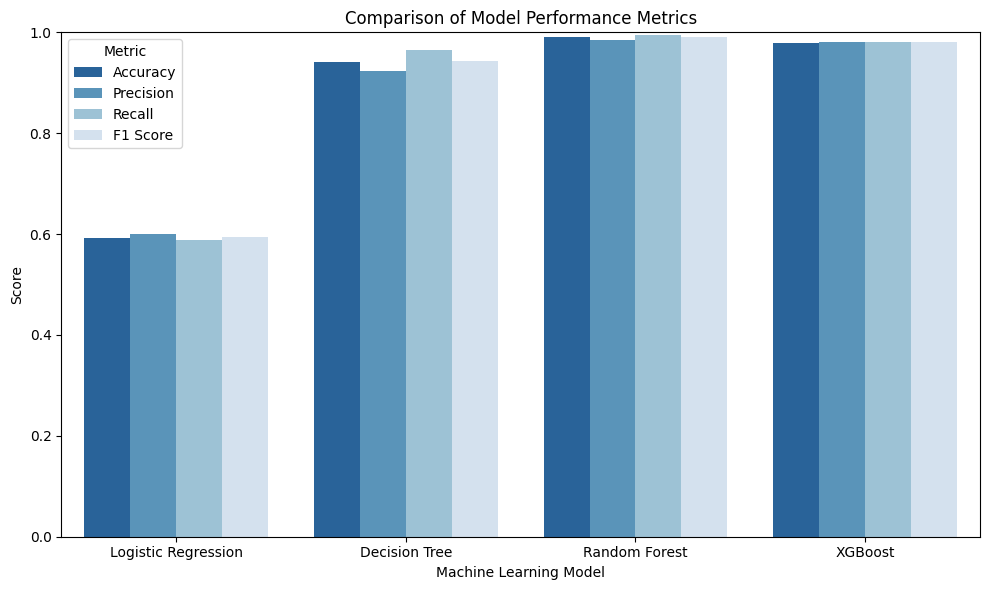

In [20]:
# ===============================================================
# MODEL PERFORMANCE COMPARISON VISUALIZATION
# ===============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Collect performance metrics
metrics_summary = []

for name, model in models.items():
    if name != "Isolation Forest":  # skip unsupervised model
        y_pred = model.predict(X_test)
        metrics_summary.append({
            "Model": name,
            "Accuracy": round(accuracy_score(y_test, y_pred), 4),
            "Precision": round(precision_score(y_test, y_pred), 4),
            "Recall": round(recall_score(y_test, y_pred), 4),
            "F1 Score": round(f1_score(y_test, y_pred), 4)
        })

# Create DataFrame
uploaded_metrics = pd.DataFrame(metrics_summary)

# Melt dataframe for grouped bar chart
uploaded_melted = uploaded_metrics.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Plot grouped bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=uploaded_melted, x="Model", y="Score", hue="Metric", palette="Blues_r")
plt.title("Comparison of Model Performance Metrics")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Machine Learning Model")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

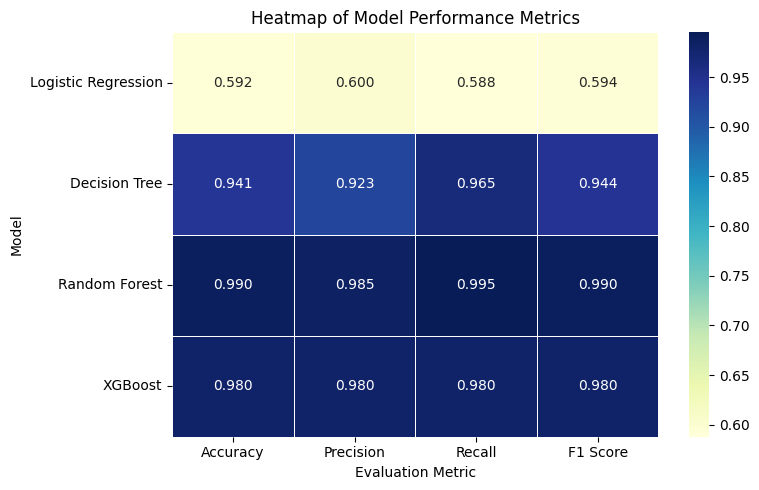

In [22]:
# ===============================================================
# MODEL PERFORMANCE HEATMAP
# ===============================================================

plt.figure(figsize=(8, 5))
sns.heatmap(uploaded_metrics.set_index("Model"), annot=True, cmap="YlGnBu", fmt=".3f", linewidths=0.5)
plt.title("Heatmap of Model Performance Metrics")
plt.ylabel("Model")
plt.xlabel("Evaluation Metric")
plt.tight_layout()
plt.show()

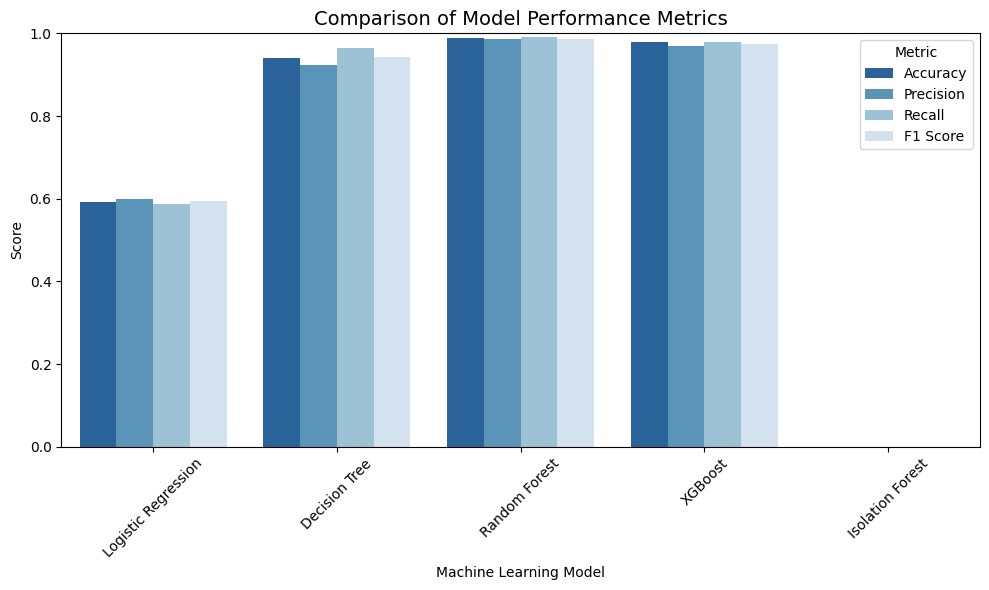

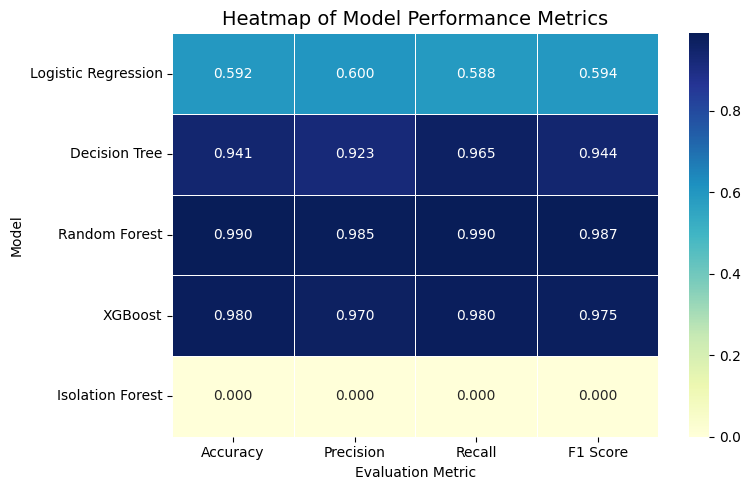

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Model evaluation data
data = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost", "Isolation Forest"],
    "Accuracy": [0.5918, 0.9413, 0.9898, 0.9800, 0.0],
    "Precision": [0.6000, 0.9231, 0.9851, 0.9700, 0.0],
    "Recall": [0.5879, 0.9648, 0.9900, 0.9800, 0.0],
    "F1 Score": [0.5939, 0.9435, 0.9870, 0.9750, 0.0],
}

df_metrics = pd.DataFrame(data)

# Melt for grouped bar chart
df_melted = df_metrics.melt(id_vars="Model", var_name="Metric", value_name="Score")

# Chart 1: Grouped Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette="Blues_r")
plt.title("Comparison of Model Performance Metrics", fontsize=14)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xlabel("Machine Learning Model")
plt.xticks(rotation=45)
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig("Model_Performance_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Chart 2: Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df_metrics.set_index("Model"), annot=True, cmap="YlGnBu", fmt=".3f", linewidths=0.5)
plt.title("Heatmap of Model Performance Metrics", fontsize=14)
plt.ylabel("Model")
plt.xlabel("Evaluation Metric")
plt.tight_layout()
plt.savefig("Model_Performance_Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
